# MCMC fitting of a star cluster CMD with MADYS

This notebook shows how to use the MADYS MCMC module to fit the **color-magnitude diagram (CMD)** of a star cluster and recover

- the cluster **age** (log10 age in Myr),
- the **distance modulus** $\mu$,
- the **interstellar reddening** $E(B-V)$.

Compared to single-star fitting, a cluster gives us many stars drawn from a common isochrone, so the stellar masses become **nuisance parameters**: we marginalize them out analytically using an IMF-weighted integral along the isochrone. Only $(\log_{10} \tau, \mu, E(B-V))$ remain as free cluster-level parameters.

We will:

1. Generate a synthetic Pleiades-like cluster drawn from MIST.
2. Run `madys.mcmc.run_cluster_mcmc` against MIST and recover the injected parameters.
3. Repeat with PARSEC2 and compare the posteriors.

> **Dependencies**: `emcee`, `corner`. Install with `pip install emcee corner` if needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from madys.madys import IsochroneGrid, SampleObject
from madys import mcmc

np.random.seed(42)

## 1. Build an isochrone interpolator for the Gaia bands

We fit in a Gaia-only CMD: $G$ versus $G_{BP}-G_{RP}$. This is the standard cluster CMD today thanks to Gaia DR3.

In [2]:
filters = ['G', 'Gbp', 'Grp']
color_filters = ('Gbp', 'Grp')  # color = Gbp - Grp
mag_filter = 'G'                 # y-axis of the CMD

mass_range = (0.3, 3.0)    # Msun
age_range  = (10.0, 1000.0)  # Myr
grid_steps = (200, 200)

grid_mist    = IsochroneGrid('mist',    filters, mass_range=list(mass_range),
                             age_range=list(age_range), n_steps=list(grid_steps))
grid_parsec2 = IsochroneGrid('parsec2', filters, mass_range=list(mass_range),
                             age_range=list(age_range), n_steps=list(grid_steps))

interp_mist    = mcmc.IsochroneInterpolator(grid_mist)
interp_parsec2 = mcmc.IsochroneInterpolator(grid_parsec2)

print(interp_mist)
print(interp_parsec2)

IsochroneInterpolator(model='mist', filters=[np.str_('G'), np.str_('Gbp'), np.str_('Grp')], log_age=(1.0000434272768626, 2.999956568380192), log_mass=(-0.5233132570543553, 0.47755533219898105))
IsochroneInterpolator(model='parsec2', filters=[np.str_('G'), np.str_('Gbp'), np.str_('Grp')], log_age=(1.0000434272768626, 2.999956568380192), log_mass=(-0.5233132570543553, 0.47755533219898105))


## 2. Inject a synthetic cluster

We simulate a 300-star cluster with Pleiades-like parameters:

- age $\tau = 100$ Myr,
- distance modulus $\mu = 5.5$ (about 125 pc),
- reddening $E(B-V) = 0.04$.

Masses are drawn from a Salpeter power law ($\mathrm{d}N/\mathrm{d}m \propto m^{-2.35}$), then we use the MIST interpolator to compute each star's absolute magnitudes, apply distance and extinction, and finally add per-star photometric noise.

In [3]:
truth_age_Myr = 100.0
truth_mu      = 5.5
truth_ebv     = 0.04

la_true  = np.log10(truth_age_Myr)


def draw_salpeter(n, m_min=0.35, m_max=2.5, alpha=2.35, rng=None):
    """Inverse-CDF sampler for a power-law IMF with exponent alpha."""
    rng = np.random.default_rng(rng)
    u = rng.uniform(size=n)
    a = 1.0 - alpha
    return ((m_max**a - m_min**a) * u + m_min**a) ** (1.0 / a)


n_stars = 300
rng = np.random.default_rng(123)
masses_true = draw_salpeter(n_stars, rng=rng)

abs_mags = interp_mist.predict(
    np.full(n_stars, la_true),
    np.log10(masses_true),
)  # shape (n_stars, 3)

A_G   = SampleObject.extinction(truth_ebv, 'G')
A_Gbp = SampleObject.extinction(truth_ebv, 'Gbp')
A_Grp = SampleObject.extinction(truth_ebv, 'Grp')

color_intrinsic = abs_mags[:, 1] - abs_mags[:, 2]
color_obs = color_intrinsic + (A_Gbp - A_Grp)
mag_obs   = abs_mags[:, 0] + truth_mu + A_G

color_err = 0.02 * np.ones(n_stars)
mag_err   = 0.03 * np.ones(n_stars)

color_obs = color_obs + color_err * rng.standard_normal(n_stars)
mag_obs   = mag_obs   + mag_err   * rng.standard_normal(n_stars)

good = np.isfinite(color_obs) & np.isfinite(mag_obs)
color_obs = color_obs[good]; mag_obs = mag_obs[good]
color_err = color_err[good]; mag_err = mag_err[good]
print(f'{good.sum()} synthetic stars retained.')

300 synthetic stars retained.


### 2a. Look at the synthetic CMD with the true isochrone overlaid

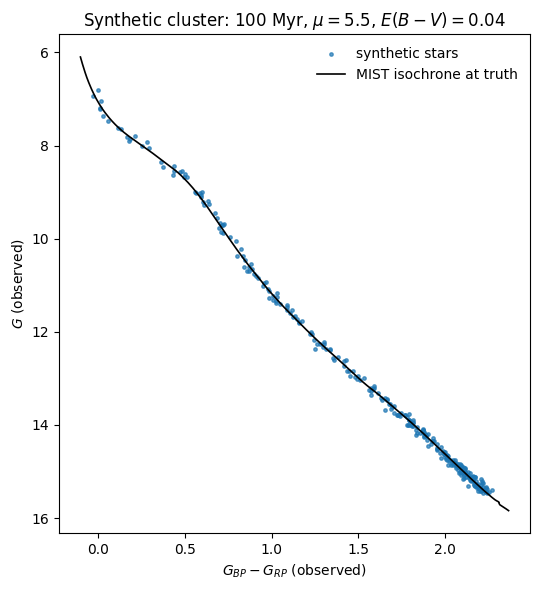

In [4]:
mass_grid = interp_mist.masses
iso_abs = interp_mist.predict(np.full_like(np.log10(mass_grid), la_true),
                              np.log10(mass_grid))
iso_color = (iso_abs[:, 1] - iso_abs[:, 2]) + (A_Gbp - A_Grp)
iso_mag   = iso_abs[:, 0] + truth_mu + A_G

fig, ax = plt.subplots(figsize=(5.5, 6))
ax.scatter(color_obs, mag_obs, s=6, color='C0', alpha=0.7, label='synthetic stars')
ax.plot(iso_color, iso_mag, 'k-', lw=1.2, label='MIST isochrone at truth')
ax.invert_yaxis()
ax.set_xlabel(r'$G_{BP} - G_{RP}$ (observed)')
ax.set_ylabel(r'$G$ (observed)')
ax.set_title(f'Synthetic cluster: {truth_age_Myr:.0f} Myr, $\\mu={truth_mu}$, $E(B-V)={truth_ebv}$')
ax.legend(frameon=False)
fig.tight_layout()

## 3. Fit the cluster with MCMC (MIST)

The likelihood is an IMF-weighted integral over the isochrone; we set a flat prior on each of $(\log \tau, \mu, E(B-V))$.

In [5]:
res_mist = mcmc.run_cluster_mcmc(
    color_obs, mag_obs, color_err, mag_err,
    color_filters=color_filters, mag_filter=mag_filter,
    model_version='mist',
    mu_range=(3.0, 8.0), ebv_range=(0.0, 0.3),
    age_range=age_range, mass_range=mass_range,
    n_walkers=32, n_steps=3000, burn_in=1000,
    interpolator=interp_mist, seed=1,
)

summary_mist = mcmc.cluster_mcmc_summary(res_mist)
for key, value in summary_mist.items():
    print(f'{key}: {value}')

log10_age_Myr: {'median': 2.0113100967786477, 'lower_1sigma': 0.007165334451018968, 'upper_1sigma': 0.007341276922668172}
distance_modulus: {'median': 5.427009089627646, 'lower_1sigma': 0.012432415943192332, 'upper_1sigma': 0.02282200549345692}
ebv: {'median': 0.008841080404968178, 'lower_1sigma': 0.004775055579199548, 'upper_1sigma': 0.009336413561642071}
age_Myr_median: 102.63845280845388
distance_pc_median: 121.73117609234669


### 3a. Walker traces

Sanity-check that the chains have converged.

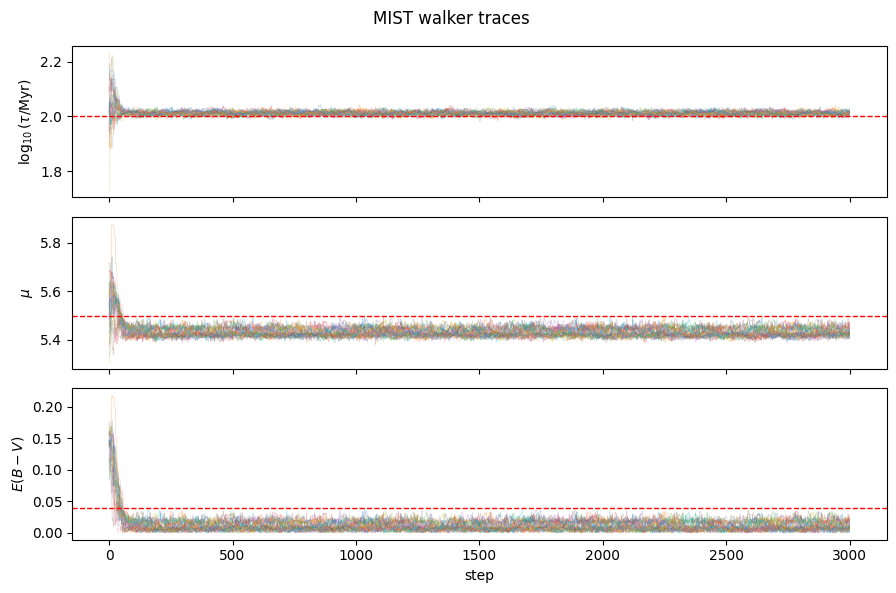

In [6]:
def plot_cluster_traces(result, truths=None, title=''):
    chain = result['sampler'].get_chain()  # shape (n_steps, n_walkers, n_dim)
    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    labels = [
        r'$\log_{10}(\tau/\mathrm{Myr})$',
        r'$\mu$',
        r'$E(B-V)$',
    ]
    for i, ax in enumerate(axes):
        ax.plot(chain[:, :, i], alpha=0.3, lw=0.5)
        ax.set_ylabel(labels[i])
        if truths is not None:
            ax.axhline(truths[i], color='r', ls='--', lw=1)
    axes[-1].set_xlabel('step')
    fig.suptitle(title)
    fig.tight_layout()
    return fig

plot_cluster_traces(res_mist, truths=[la_true, truth_mu, truth_ebv],
                    title='MIST walker traces');

### 3b. Corner plot with truth values

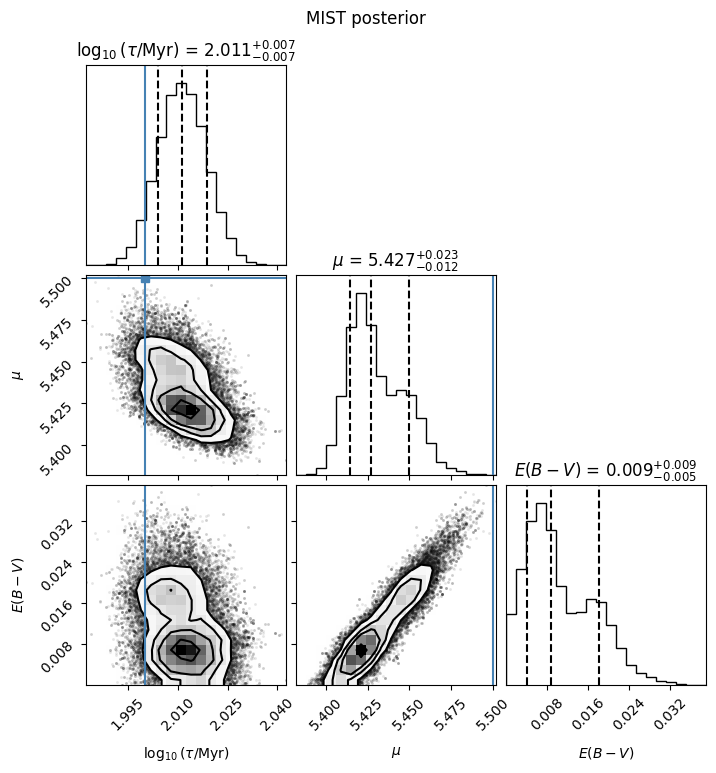

In [7]:
import corner

labels = [r'$\log_{10}(\tau/\mathrm{Myr})$', r'$\mu$', r'$E(B-V)$']

fig = corner.corner(
    res_mist['samples'], labels=labels,
    truths=[la_true, truth_mu, truth_ebv],
    show_titles=True, title_fmt='.3f',
    quantiles=[0.16, 0.5, 0.84],
)
fig.suptitle('MIST posterior', y=1.02);

### 3c. Best-fit isochrone overlaid on the CMD

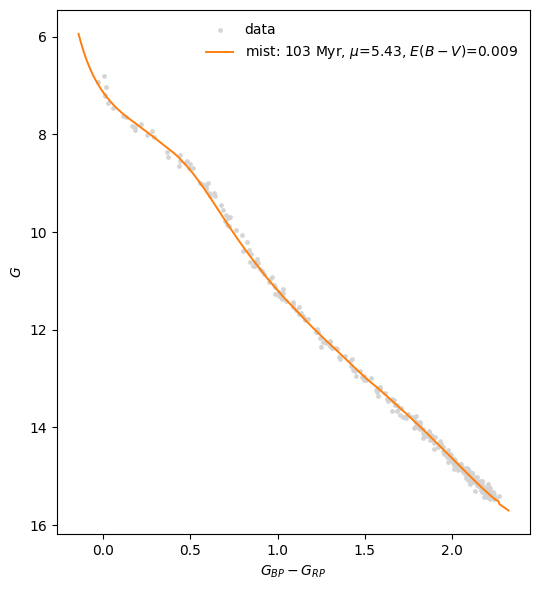

In [8]:
def overlay_best_fit(result, color_obs, mag_obs, truth_params,
                     color='C1', label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 6))
    s = mcmc.cluster_mcmc_summary(result)
    la_med = s['log10_age_Myr']['median']
    mu_med = s['distance_modulus']['median']
    ebv_med = s['ebv']['median']

    interp = result['interpolator']
    mass_grid = interp.masses
    iso = interp.predict(np.full_like(np.log10(mass_grid), la_med),
                         np.log10(mass_grid))
    cf = result['color_filters']
    mf = result['mag_filter']
    filters_list = list(interp.filters)
    c1, c2 = filters_list.index(cf[0]), filters_list.index(cf[1])
    m = filters_list.index(mf)
    A_c1 = SampleObject.extinction(ebv_med, cf[0])
    A_c2 = SampleObject.extinction(ebv_med, cf[1])
    A_m  = SampleObject.extinction(ebv_med, mf)
    color_iso = (iso[:, c1] - iso[:, c2]) + (A_c1 - A_c2)
    mag_iso = iso[:, m] + mu_med + A_m
    lab = label or f"{result['model_version']}: {s['age_Myr_median']:.0f} Myr, "\
                   f"$\\mu$={mu_med:.2f}, $E(B-V)$={ebv_med:.3f}"
    ax.plot(color_iso, mag_iso, '-', color=color, lw=1.4, label=lab)
    return ax

fig, ax = plt.subplots(figsize=(5.5, 6))
ax.scatter(color_obs, mag_obs, s=6, color='lightgray', alpha=0.9, label='data')
overlay_best_fit(res_mist, color_obs, mag_obs,
                 truth_params=(la_true, truth_mu, truth_ebv),
                 color='C1', ax=ax)
ax.invert_yaxis()
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$G$')
ax.legend(frameon=False)
fig.tight_layout()

## 4. Repeat with PARSEC2 and compare posteriors

Different physics ingredients (opacities, convection prescription, boundary conditions) lead different isochrone families to predict slightly different cluster parameters for the same observed CMD. Cross-checking is a light-weight systematics budget.

In [9]:
res_parsec2 = mcmc.run_cluster_mcmc(
    color_obs, mag_obs, color_err, mag_err,
    color_filters=color_filters, mag_filter=mag_filter,
    model_version='parsec2',
    mu_range=(3.0, 8.0), ebv_range=(0.0, 0.3),
    age_range=age_range, mass_range=mass_range,
    n_walkers=32, n_steps=3000, burn_in=1000,
    interpolator=interp_parsec2, seed=1,
)

summary_parsec2 = mcmc.cluster_mcmc_summary(res_parsec2)

print('truth:   log_age = %.3f, mu = %.3f, E(B-V) = %.3f' % (la_true, truth_mu, truth_ebv))
print('-' * 70)
for name, s in [('mist', summary_mist), ('parsec2', summary_parsec2)]:
    la = s['log10_age_Myr']; mu = s['distance_modulus']; eb = s['ebv']
    print(f"{name:>8s}: log_age = {la['median']:.3f} (+{la['upper_1sigma']:.3f}/-{la['lower_1sigma']:.3f}), "
          f"age = {s['age_Myr_median']:5.1f} Myr, "
          f"mu = {mu['median']:.3f} (+{mu['upper_1sigma']:.3f}/-{mu['lower_1sigma']:.3f}), "
          f"E(B-V) = {eb['median']:.3f} (+{eb['upper_1sigma']:.3f}/-{eb['lower_1sigma']:.3f})")

truth:   log_age = 2.000, mu = 5.500, E(B-V) = 0.040
----------------------------------------------------------------------
    mist: log_age = 2.011 (+0.007/-0.007), age = 102.6 Myr, mu = 5.427 (+0.023/-0.012), E(B-V) = 0.009 (+0.009/-0.005)
 parsec2: log_age = 2.227 (+0.011/-0.005), age = 168.6 Myr, mu = 6.156 (+0.007/-0.006), E(B-V) = 0.143 (+0.004/-0.003)


### 4a. Overlaid marginal posteriors

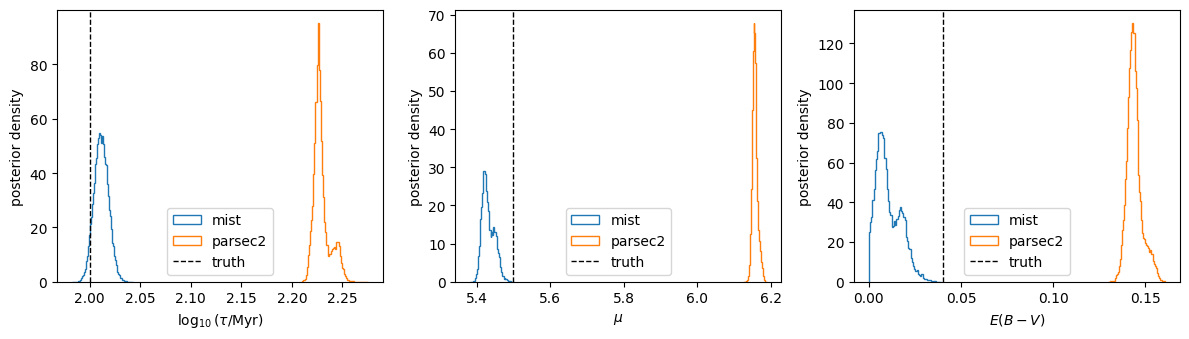

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for model, color, res in [('mist', 'tab:blue', res_mist),
                          ('parsec2', 'tab:orange', res_parsec2)]:
    samples = res['samples']
    axes[0].hist(samples[:, 0], bins=60, density=True, histtype='step',
                 color=color, label=model)
    axes[1].hist(samples[:, 1], bins=60, density=True, histtype='step',
                 color=color, label=model)
    axes[2].hist(samples[:, 2], bins=60, density=True, histtype='step',
                 color=color, label=model)

for ax, truth, label in zip(
    axes, [la_true, truth_mu, truth_ebv],
    [r'$\log_{10}(\tau/\mathrm{Myr})$', r'$\mu$', r'$E(B-V)$']
):
    ax.axvline(truth, color='k', linestyle='--', lw=1, label='truth')
    ax.set_xlabel(label)
    ax.set_ylabel('posterior density')
    ax.legend()
fig.tight_layout()

### 4b. Stacked corner plot (MIST vs PARSEC2)

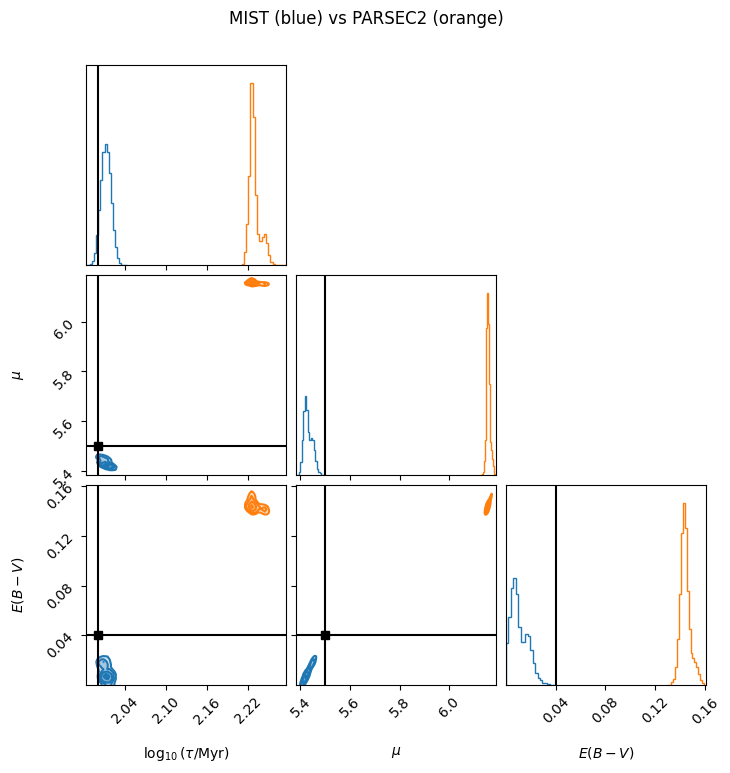

In [11]:
fig = corner.corner(
    res_mist['samples'], color='tab:blue', labels=labels,
    truths=[la_true, truth_mu, truth_ebv], truth_color='k',
    plot_datapoints=False, plot_density=False, fill_contours=True,
    hist_kwargs={'density': True},
)
corner.corner(
    res_parsec2['samples'], color='tab:orange', fig=fig,
    plot_datapoints=False, plot_density=False, fill_contours=True,
    hist_kwargs={'density': True},
)
fig.suptitle('MIST (blue) vs PARSEC2 (orange)', y=1.02);

### 4c. Best-fit isochrones side-by-side on the CMD

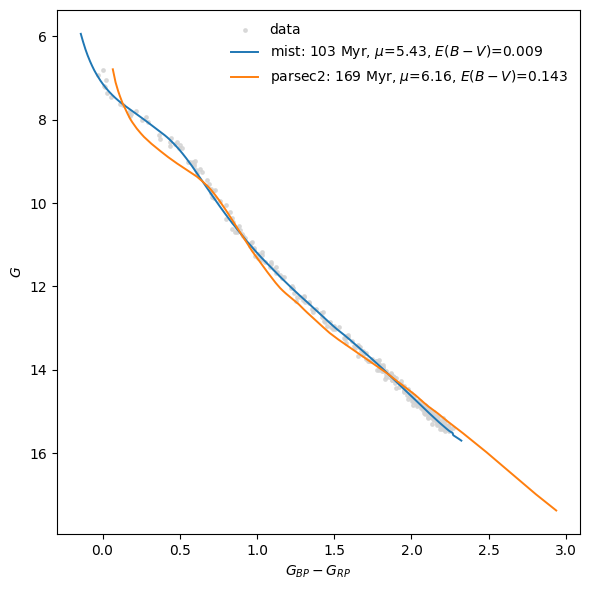

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(color_obs, mag_obs, s=6, color='lightgray', alpha=0.8, label='data')
overlay_best_fit(res_mist, color_obs, mag_obs,
                 truth_params=(la_true, truth_mu, truth_ebv),
                 color='tab:blue', ax=ax)
overlay_best_fit(res_parsec2, color_obs, mag_obs,
                 truth_params=(la_true, truth_mu, truth_ebv),
                 color='tab:orange', ax=ax)
ax.invert_yaxis()
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$G$')
ax.legend(frameon=False)
fig.tight_layout()

## 5. Notes

- **Likelihood model**: for each observed star the likelihood is the IMF-weighted integral of a 2D Gaussian (diagonal covariance assumed) over all masses on the isochrone. This treats per-star mass as a nuisance parameter that is analytically marginalized.
- **IMF slope**: controlled by the `imf_alpha` keyword of `run_cluster_mcmc` (Salpeter is 2.35).
- **Extinction law**: by default we use `madys.SampleObject.extinction`, which applies the Cardelli-like $A_\lambda / E(B-V)$ coefficients shipped with MADYS. Pass a custom `extinction_fn(ebv, filter_name)` to use a different law.
- **Binary stars, field contamination**: a single isochrone model naturally pulls away from sequences generated by unresolved binaries or field stars. For real Gaia data you would typically pre-clean the sample with a parallax+proper-motion cut and optionally widen the likelihood with an outlier mixture (e.g. a broad Gaussian component).
- **Metallicity**: pass `feh=0.2` (or any other model parameter supported by `IsochroneGrid`) through `run_cluster_mcmc` to switch to a non-solar grid.